In [1]:
import sys
from pathlib import Path

import cv2 as cv
from ultralytics import YOLO
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ecg_scanner.scanner import ECGScanner, ECGScannerConfig
from ecg_digitizer.config import DigitizerConfig  # noqa: E402
from ecg_digitizer.digitizer import ecg_to_csv  # noqa: E402
from ecg_digitizer.utils import create_zip, plot_ecg  # noqa: E402

MODELS_DIR = PROJECT_ROOT / "models"
IMAGES_DIR = PROJECT_ROOT / "datasets" / "samples"
%matplotlib inline

In [2]:
def load_models():
    return YOLO(str(MODELS_DIR / "best.pt")), YOLO(str(MODELS_DIR / "labels.pt"))


model, label_model = load_models()
scanner = ECGScanner()

In [3]:
lead_time = 2.5
sample_frequency = 500
mm_per_sec = 25
pulse_width_mm = 500

pulse_per_sec = pulse_width_mm / mm_per_sec
num_sampling_points = int(lead_time * sample_frequency)

lead_order = [
    "I",
    "aVR",
    "V1",
    "V4",
    "II",
    "aVL",
    "V2",
    "V5",
    "III",
    "aVF",
    "V3",
    "V6",
]

In [4]:
num_sampling_points

1250

In [5]:
%%script false --no-raise-error

file_path = IMAGES_DIR / "1048962695-0006.png"
csv_name = file_path.stem + ".csv"

config = DigitizerConfig(
    image=file_path,
    csv_name=csv_name,
    pulse_per_sec=pulse_per_sec,
    sample_frequency=sample_frequency,
    num_sampling_points=num_sampling_points,
)

img = cv.imread(config.image)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
results = model(config.image)
result = results[0]

label_boxes = []
if label_model is not None:
    label_results = label_model(config.image)
    for box in label_results[0].boxes:
        lx1, ly1, lx2, ly2 = map(int, box.xyxy[0].tolist())
        label_boxes.append((lx1, ly1, lx2, ly2))

pulse_boxes = [
    box for box in result.boxes if model.names[int(box.cls[0])].lower() == "pulse"
]
if pulse_boxes:
    x1, y1, x2, y2 = map(int, pulse_boxes[0].xyxy[0].tolist())
    pulse_per_mv = (y2 - y1) / 1.0
else:
    pulse_per_mv = 10.0

## Visualização passo a passo do pipeline de digitalização


## Passo 0 - Ler a imagem 

In [6]:

file_path = IMAGES_DIR / "1048962695-0006.png"
csv_name = file_path.stem + ".csv"

config = DigitizerConfig(
    image=file_path,
    csv_name=csv_name,
    pulse_per_sec=pulse_per_sec,
    sample_frequency=sample_frequency,
    num_sampling_points=num_sampling_points,
)


In [7]:

img = cv.imread(config.image)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


### Passo 1 e 2 — Imagem original e conversão para grayscale


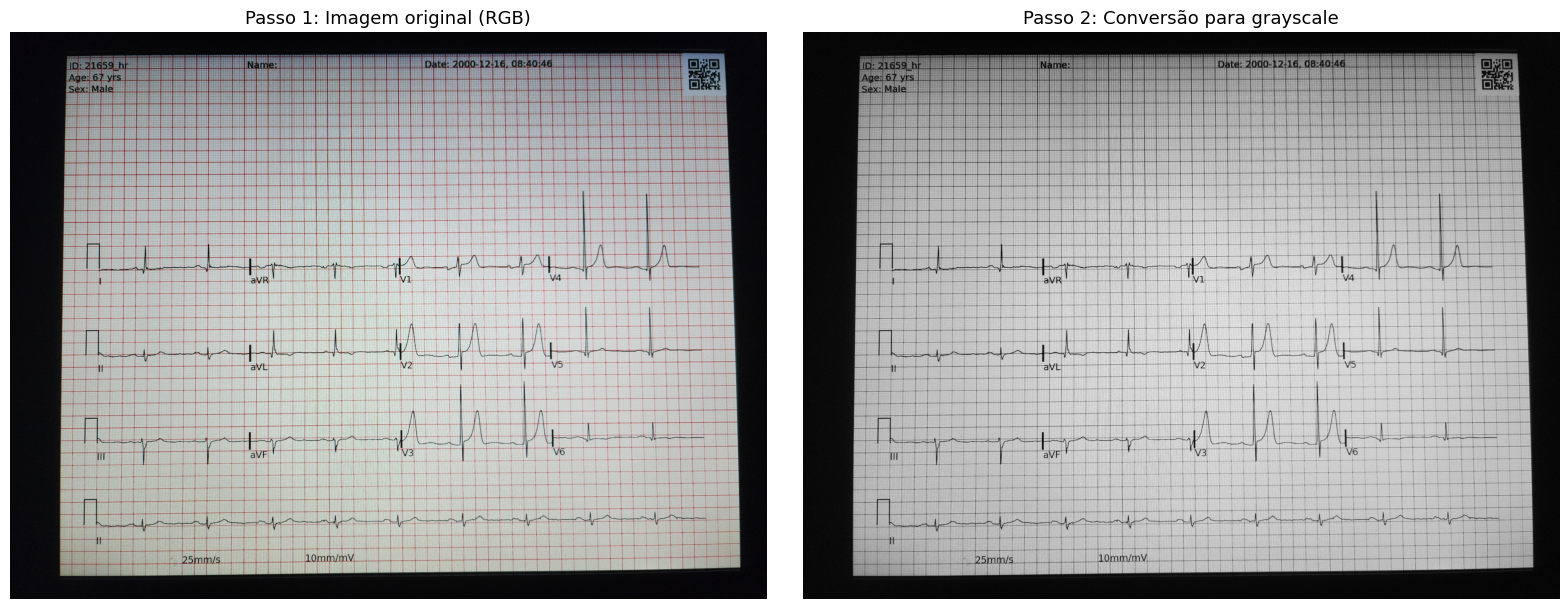

In [8]:
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Passo 1: Imagem original (RGB)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("Passo 2: Conversão para grayscale", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Passo 3 — Detecções YOLO: leads e pulso de calibração


In [9]:
results = model(config.image)
result = results[0]


image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 768x1024 4 pulses, 1 I, 1 aVR, 1 V1, 1 V4, 1 II, 1 aVL, 1 V2, 1 V5, 1 III, 1 aVF, 1 V3, 1 V6, 16.6ms
Speed: 2.5ms preprocess, 16.6ms inference, 15.5ms postprocess per image at shape (1, 3, 768, 1024)


In [10]:
label_boxes = []
if label_model is not None:
    label_results = label_model(config.image)
    for box in label_results[0].boxes:
        lx1, ly1, lx2, ly2 = map(int, box.xyxy[0].tolist())
        label_boxes.append((lx1, ly1, lx2, ly2))

pulse_boxes = [
    box for box in result.boxes if model.names[int(box.cls[0])].lower() == "pulse"
]


image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 1536x2048 13 labels, 22.2ms
Speed: 7.8ms preprocess, 22.2ms inference, 0.5ms postprocess per image at shape (1, 3, 1536, 2048)


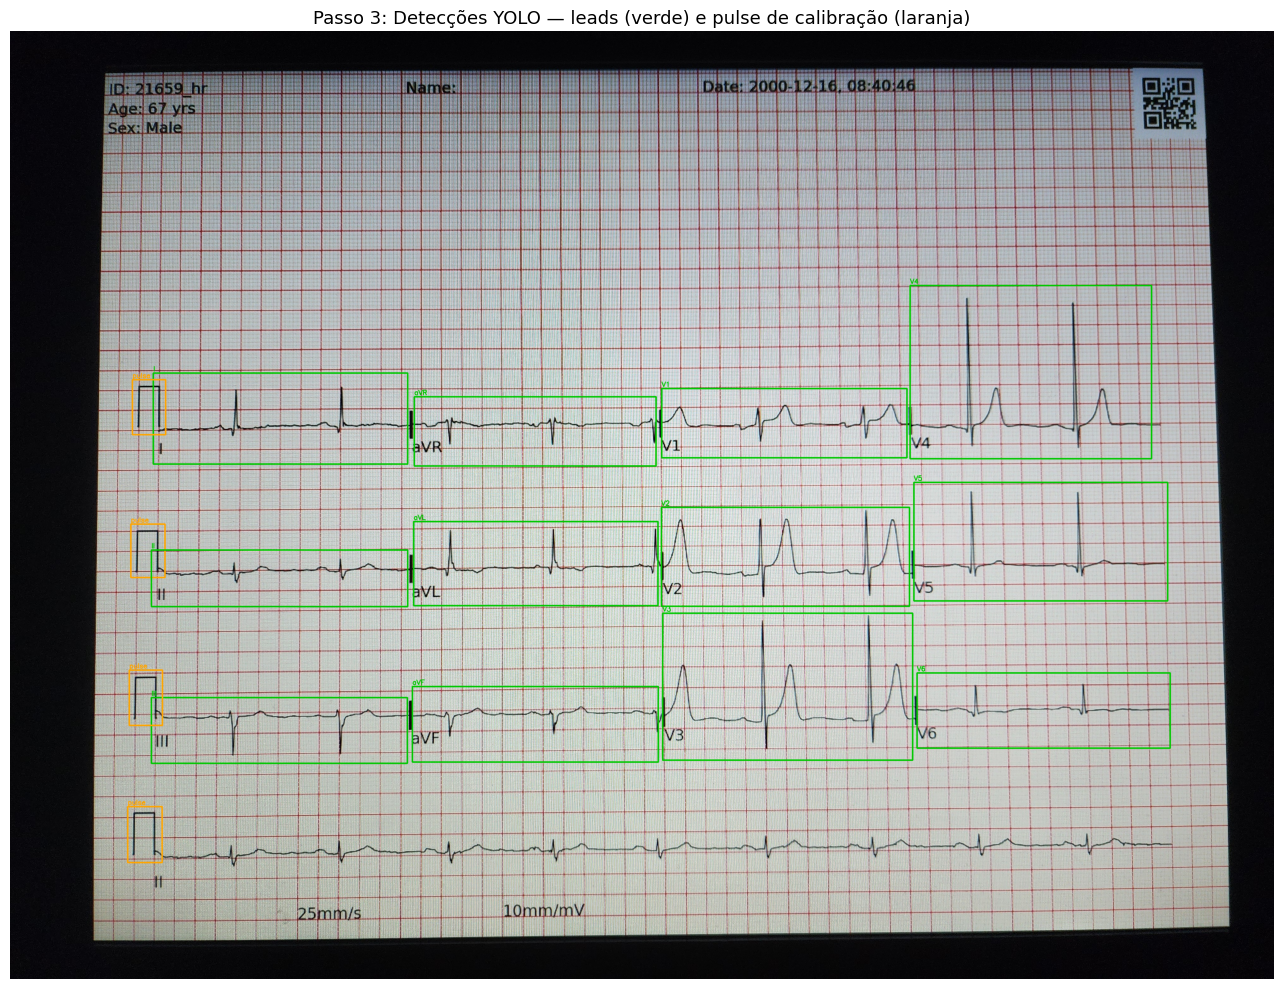

In [11]:
viz = img_rgb.copy()
boxes = dict()
for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    cls_id = int(box.cls[0])
    lead_name = model.names[cls_id]
    boxes[lead_name] = corners = np.array(
        [
            [x1, y1],  # top-left
            [x2, y1],  # top-right
            [x2, y2],  # bottom-right
            [x1, y2],  # bottom-left
        ]
    )
    color = (255, 165, 0) if lead_name.lower() == "pulse" else (0, 200, 0)
    cv.rectangle(viz, (x1, y1), (x2, y2), color, 3)
    cv.putText(viz, lead_name, (x1, y1 - 6), cv.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(viz)
ax.set_title(
    "Passo 3: Detecções YOLO — leads (verde) e pulse de calibração (laranja)",
    fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.show()

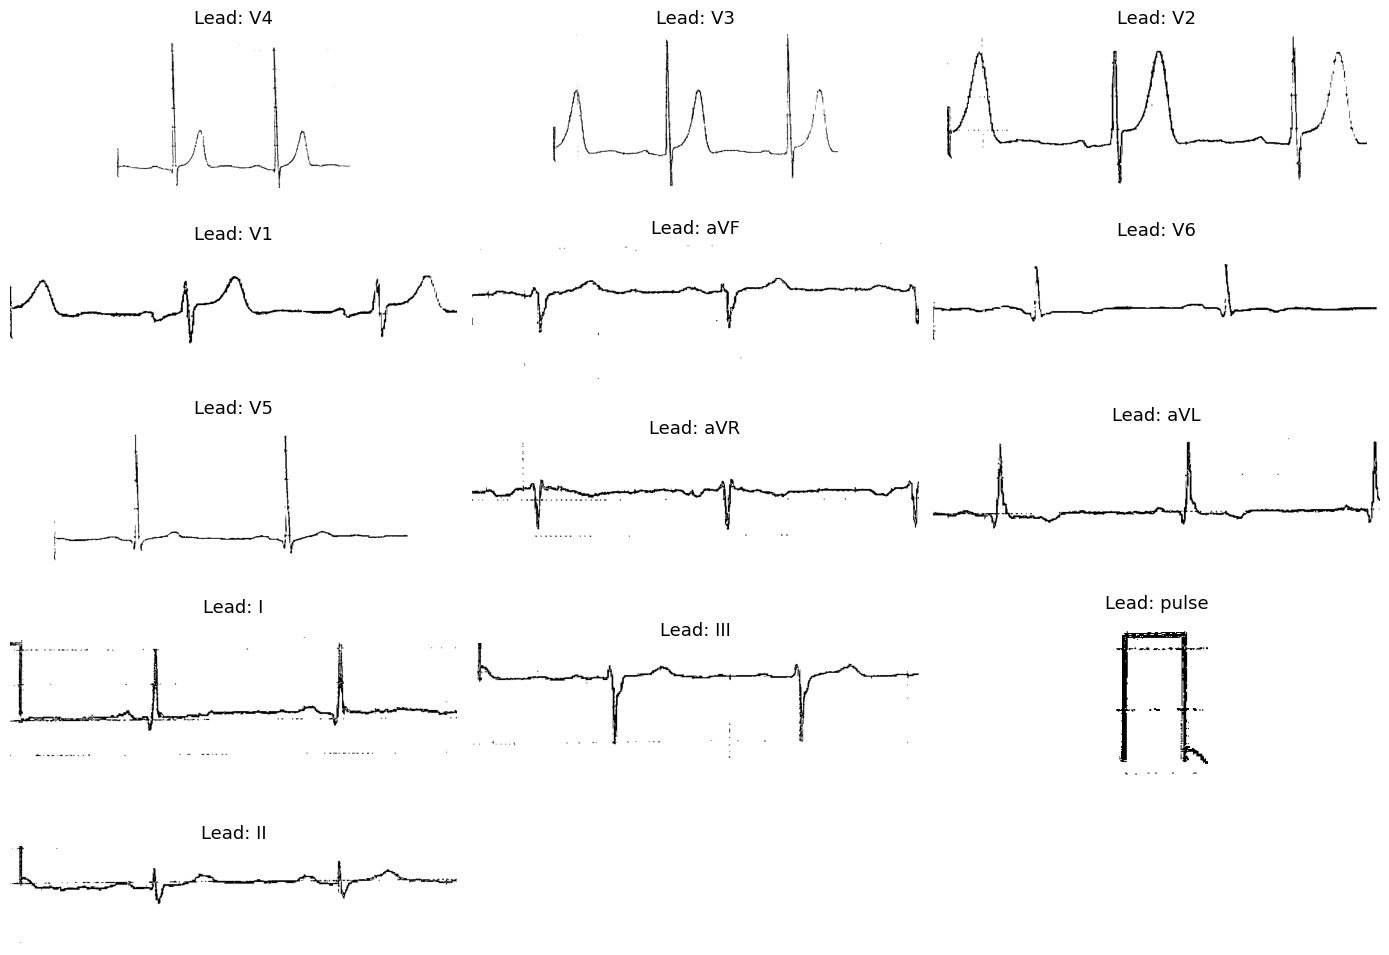

In [12]:
scanner = ECGScanner(
    v_margin=90, s_margin=60, fill_value=255, dark_percentile=10, s_quantile_offset=0.4
)
image_boxes = scanner.scan_yolo(image=img, lead_boxes=boxes, label_boxes=label_boxes)
fig, ax = plt.subplots(nrows=(len(image_boxes) // 3) + 1, ncols=3, figsize=(14, 10))
ax = ax.flatten()

for i, (lead_name, img_lead) in enumerate(image_boxes.items()):
    ax[i].imshow(img_lead, cmap="gray")
    ax[i].set_title(
        f"Lead: {lead_name}",
        fontsize=13,
    )
    ax[i].axis("off")
for j in range(len(image_boxes), len(ax)):
    fig.delaxes(ax[j])
plt.tight_layout()
plt.show()

### Passo 6 — Overlay final: curvas sobrepostas na imagem original


In [13]:
from ecg_digitizer.utils import interpolate_segment

In [14]:
df = ecg_to_csv(config, model, label_model, )


image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 768x1024 4 pulses, 1 I, 1 aVR, 1 V1, 1 V4, 1 II, 1 aVL, 1 V2, 1 V5, 1 III, 1 aVF, 1 V3, 1 V6, 5.5ms
Speed: 2.4ms preprocess, 5.5ms inference, 0.6ms postprocess per image at shape (1, 3, 768, 1024)

image 1/1 /home/luan-rodrigues/faculdade/ecg-digitization-tool/datasets/samples/1048962695-0006.png: 1536x2048 13 labels, 16.5ms
Speed: 8.1ms preprocess, 16.5ms inference, 0.6ms postprocess per image at shape (1, 3, 1536, 2048)
764 1250
791 1250
785 1250
776 1250
778 1250
801 1250
803 1250
765 1250
773 1250
805 1250
810 1250
811 1250


<Axes: >

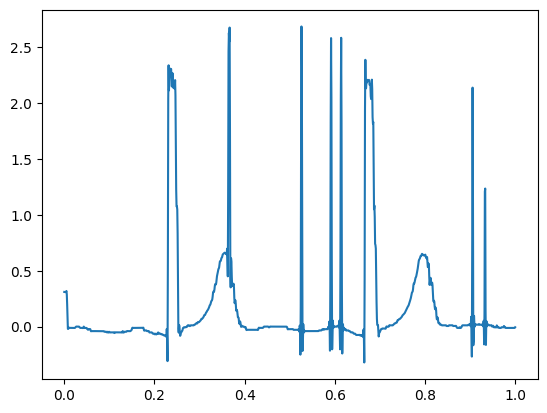

In [15]:
df["v4"].plot(kind="line")